In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from roll_model import roll_estimator, infer_trade_direction, roll_efficient_price

In [2]:
#datos
df = pd.read_csv('data/btc_project_train.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.head()

,Timestamp,Gmtoffset,Datetime,Open,High,Low,Close,Volume
0,1654041600,0,2022-06-01 00:00:00,31803.693359,31834.984375,31803.693359,31834.984375,NaN
1,1654041900,0,2022-06-01 00:05:00,31834.910156,31853.056640,31834.910156,31853.056640,NaN
2,1654042200,0,2022-06-01 00:10:00,31854.175781,31854.175781,31747.339843,31747.378906,NaN
3,1654042500,0,2022-06-01 00:15:00,31750.771484,31840.392578,31750.771484,31840.392578,39202816.0
4,1654042800,0,2022-06-01 00:20:00,31844.460937,31844.460937,31777.644531,31777.644531,NaN


In [3]:
df = df.dropna(subset=['Close']).reset_index(drop=True)

p = df['Close'].values

print(f"Rango de fechas: {df['Datetime'].min()}  ->  {df['Datetime'].max()}")
print(f"Numero de observaciones: {len(df):,}")
print(f"Precio medio: {p.mean():,.2f} USD")

Rango de fechas: 2022-06-01 00:00:00  ->  2023-12-31 00:00:00
Numero de observaciones: 162,705
Precio medio: 25,659.05 USD


In [4]:
s_full, sigma_u_full, cov_full = roll_estimator(p)

print(f"Cov(dP_t, dP_t-1) = {cov_full:.4f}")
print(f"s = {s_full}")
print(f"sigma_u = {sigma_u_full}")

Cov(dP_t, dP_t-1) = 64.3660
s = nan
sigma_u = nan


**Por qué `s` sale `nan`:**

El modelo de Roll necesita Cov(dP_t, dP_{t-1}) < 0 para poder sacar la raíz
cuadrada (s² = -4·Cov). Aquí la covarianza salió positiva (+64.37), así que
`s` no está definido y no lo forzamos con `abs()` porque sería inventar
un número que el modelo no respalda.

La razón es que BTC tuvo una tendencia fuerte en este periodo: cayó de
$31,800 a $15,600 y luego subió hasta $42,200. Cuando un activo tiene
tendencia, los cambios de precio se repiten en la misma dirección
(momentum → covarianza positiva), y eso tapa por completo el efecto de
bid-ask bounce que el modelo de Roll busca capturar (que da covarianza
negativa).

In [5]:
N = 500  #periodos

dp = pd.Series(np.diff(p))
dp_lag = dp.shift(1)

roll_cov_series = dp.rolling(N).cov(dp_lag)  
valid = roll_cov_series[N:] < 0  

frac_valid = valid.mean()

print(f"N = {N}")
print(f"Fraccion de ventanas con Cov < 0 (estimador definido): {frac_valid:.2%}")
print(f"Fraccion de ventanas con Cov >= 0 (estimador NO definido): {1-frac_valid:.2%}")

N = 500
Fraccion de ventanas con Cov < 0 (estimador definido): 28.05%
Fraccion de ventanas con Cov >= 0 (estimador NO definido): 71.95%


**Interpretación:** incluso en ventanas cortas (500 periodos ≈ 1.7 días),
solo 28.05% tiene el estimador definido. Esto confirma que la tendencia de
BTC en este periodo es tan persistente que domina la microestructura en
la mayoría de las ventanas, incluso a escalas de horas. El bid-ask bounce
solo "gana" (Cov < 0) en los tramos donde el precio se mueve lateral, sin
dirección clara.

In [6]:
# buscar ventana valida (Cov < 0) en algun punto intermedio de la serie
valid_idx = np.where(roll_cov_series.fillna(False).values < 0)[0]
chosen_dp_idx = valid_idx[len(valid_idx)//2]  # tomamos una a la mitad de las validas

price_end = chosen_dp_idx + 1
price_start = price_end - N
window_price = p[price_start:price_end+1]
window_dates = df['Datetime'].values[price_start:price_end+1]

s_win, sigma_u_win, cov_win = roll_estimator(window_price)
q_win = infer_trade_direction(window_price)
m_win = roll_efficient_price(window_price, s_win, q_win)

print(f"Fecha de la ventana: {pd.Timestamp(window_dates[0])} -> {pd.Timestamp(window_dates[-1])}")
print(f"Cov(dP_t, dP_t-1) en la ventana: {cov_win:.4f}")
print(f"s estimado: {s_win:.4f} USD")
print(f"sigma_u estimado: {sigma_u_win:.4f} USD")

Fecha de la ventana: 2023-07-10 22:00:00 -> 2023-07-12 17:00:00
Cov(dP_t, dP_t-1) en la ventana: -45.3655
s estimado: 13.4708 USD
sigma_u estimado: 26.4832 USD


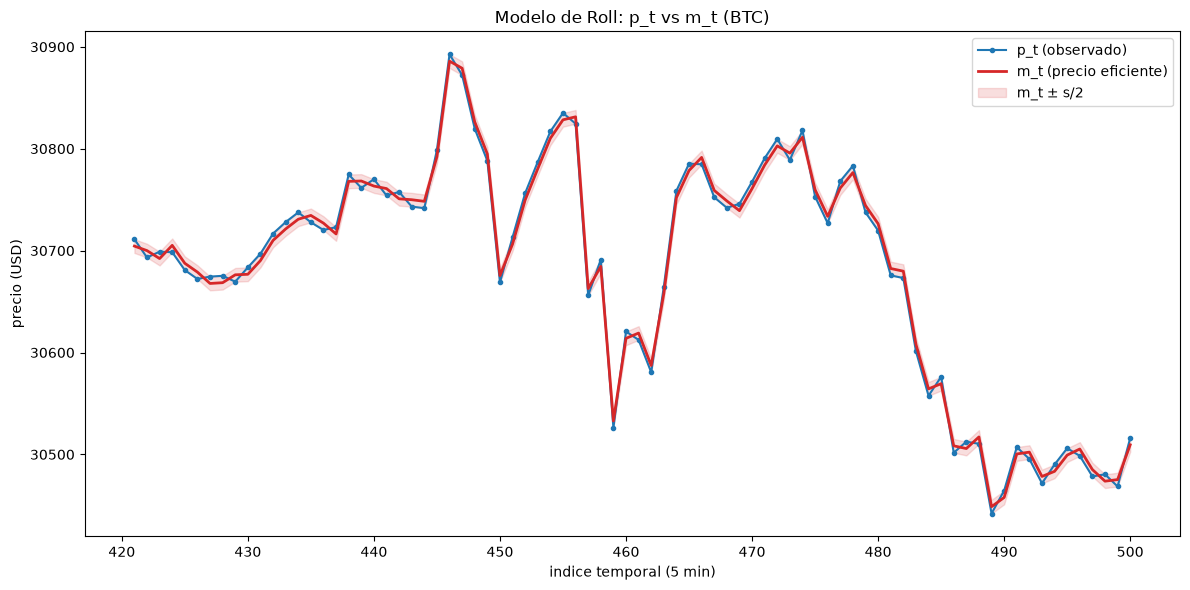

In [7]:
zoom = 80  # ultimas 80 obs de la ventana, para ver el zigzag con claridad

idx = np.arange(len(window_price))[-zoom:]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(idx, window_price[-zoom:], label='p_t (observado)', color='#1f77b4', marker='o', markersize=3)
ax.plot(idx, m_win[-zoom:], label='m_t (precio eficiente)', color='#d62728', linewidth=2)
ax.fill_between(idx, m_win[-zoom:] - s_win/2, m_win[-zoom:] + s_win/2,
                 color='#d62728', alpha=0.15, label='m_t ± s/2')
ax.set_title('Modelo de Roll: p_t vs m_t (BTC)')
ax.set_xlabel('indice temporal (5 min)')
ax.set_ylabel('precio (USD)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/roll_pt_vs_mt.png', dpi=130)
plt.show()

## Conclusiones

Conclusiones

Sobre la muestra completa (1.5 años), el estimador de Roll no esta definido (Cov mayor a 0) porque la tendencia direccional de BTC domina la microestructura.

En ventanas moviles de 500 periodos, solo 28.05% resultan validas. Esto confirma que el efecto tendencia es persistente incluso en horizontes cortos para este activo.

En la ventana valida elegida, s es aproximadamente 13.47 USD y sigma_u es aproximadamente 26.48 USD. El grafico p_t vs m_t muestra al precio observado rebotando entre los bordes de la banda m_t mas menos s/2, consistente con el mecanismo de bounce bid-ask que asume el modelo de Roll, pero esto solo se cumple localmente, en tramos sin tendencia fuerte.